## Boolean XOR Validation Harness

In [24]:
import numpy as np
import pandas as pd
from itertools import combinations

FEATURES = ["A", "B", "C", "D", "E"]


# One timestep of data: all 4 combinations of the two latent bits (u, v), each repeated `reps` times -> 100 rows.
#     A = u        B = u                  (the "u-channel")
#     C = v        D = v      E = 1 - v   (the "v-channel")
#     Y = u XOR v
def make_base_block(reps=25):
    u = np.array([1, 1, 0, 0])
    v = np.array([1, 0, 1, 0])
    block = pd.DataFrame({
        "A": u,
        "B": u,
        "C": v,
        "D": v,
        "E": 1 - v,
        "Y": u ^ v,
    })
    return pd.concat([block] * reps, ignore_index=True).astype(np.int8)


# Game-theoretic `cols -> Y` notation, computed rather than asserted. Groups rows by the values of `cols` and checks Y never disagrees within a group.
# True = this feature set pins Y down exactly.
def determines(df, cols):
    return df.groupby(list(cols), observed=True)["Y"].nunique().max() == 1


base = make_base_block()

In [25]:
assert base.shape == (100, 6)
assert (base["A"] == base["B"]).all()              # B duplicates A
assert (base["C"] == base["D"]).all()              # D duplicates C
assert (base["E"] == 1 - base["C"]).all()          # E complements C
assert (base["Y"] == (base["A"] ^ base["C"])).all()  # Y = A XOR C  (NOT A XOR B)
assert base["Y"].value_counts().to_dict() == {0: 50, 1: 50}

singletons = []
for feature in FEATURES:
    if determines(base, [feature]):
        singletons.append(feature)

pairs = []
for pair in combinations(FEATURES, 2):
    if determines(base, pair):
        pairs.append(pair)

assert singletons == [], "no single feature should determine Y"
assert set(pairs) == {("A","C"),("A","D"),("A","E"),
                      ("B","C"),("B","D"),("B","E")}

print("singletons -> Y:", singletons or "none (correct)")
print("pairs -> Y:     ", pairs)
print()
print(base.head(4).to_string(index=False))
print("\nshape:", base.shape)

singletons -> Y: none (correct)
pairs -> Y:      [('A', 'C'), ('A', 'D'), ('A', 'E'), ('B', 'C'), ('B', 'D'), ('B', 'E')]

 A  B  C  D  E  Y
 1  1  1  1  0  0
 1  1  0  0  1  1
 0  0  1  1  0  1
 0  0  0  0  1  0

shape: (100, 6)


## Drift Primitives and the Row Scheduler

Each phase touches every row exactly once, so drift accumulates at a fixed rate
and no row is mutated twice within a phase.

In [26]:
# Without-replacement row scheduler: splits every row index into `n_steps`
# disjoint groups, so after the final step the whole table has been touched exactly once and never twice.
def make_schedule(n_rows, n_steps, rng):
    assert n_rows % n_steps == 0, "n_rows must divide evenly into n_steps"
    return rng.permutation(n_rows).reshape(n_steps, n_rows // n_steps)


# P1 primitive (A <-> D): exchange two columns' values on `rows` only.
# Two-way -- both columns change. Mutates df in place.
def swap_cells(df, rows, col_x, col_y):
    x = df.loc[rows, col_x].to_numpy(copy=True)
    y = df.loc[rows, col_y].to_numpy(copy=True)
    df.loc[rows, col_x] = y
    df.loc[rows, col_y] = x


# P2 primitive (B <- E): overwrite dst with src on `rows` only.
# One-way -- src is untouched. Mutates df in place.
def copy_cells(df, rows, src, dst):
    df.loc[rows, dst] = df.loc[rows, src].to_numpy(copy=True)

In [27]:
assert isinstance(base.index, pd.RangeIndex)   # row labels == positions

rng = np.random.default_rng(0)
sched = make_schedule(len(base), n_steps=10, rng=rng)
assert sched.shape == (10, 10)
assert sorted(sched.ravel().tolist()) == list(range(100)), "must cover each row once"

df = base.copy()
rows = sched[0]
swap_cells(df, rows, "A", "D")

# labels are never touched; this is feature drift, not label noise
assert (df["Y"] == base["Y"]).all()

# columns not named in the swap are untouched
for col in ["B", "C", "E"]:
    assert (df[col] == base[col]).all()

# on the swapped rows, A now carries the v-channel and D carries the u-channel
sorted_rows = np.sort(rows)
assert (df.loc[sorted_rows, "A"] == base.loc[sorted_rows, "C"]).all()
assert (df.loc[sorted_rows, "D"] == base.loc[sorted_rows, "A"]).all()

altered = df.index[(df["A"] != base["A"]) | (df["D"] != base["D"])]
print(f"rows scheduled: {len(rows)}   rows whose values actually changed: {len(altered)}")
print("A^C -> Y ?", determines(df, ["A", "C"]))
print("B^C -> Y ?", determines(df, ["B", "C"]))
print("D^C -> Y ?", determines(df, ["D", "C"]))
print("dtypes:", set(df.dtypes.astype(str)))

rows scheduled: 10   rows whose values actually changed: 5
A^C -> Y ? False
B^C -> Y ? True
D^C -> Y ? False
dtypes: {'int8'}


## Stream Construction and Exact Reliance Enumeration

One persistent table is mutated cumulatively and snapshotted after every step.
The reliance structure is enumerated exactly, not estimated.

In [28]:
PHASES_P1P2 = [
    ("P1", "swap", ("A", "D")),      # swap A <-> D
    ("P2", "copy", ("E", "B")),      # B <- E
]

PHASES_ALL3 = PHASES_P1P2 + [("P3", "swap", ("C", "E"))]


# One persistent table, mutated cumulatively, snapshotted after every step.
# Each phase draws its own without-replacement schedule from the SAME rng, so the generator state carries from P1 into P2 and a phase touches every row exactly once across its 10 steps.
def build_stream(phases, reps=25, n_steps=10, seed=42):
    df = make_base_block(reps)
    snaps = [("t00", "baseline", df.copy())]
    rng = np.random.default_rng(seed)

    for name, kind, cols in phases:
        sched = make_schedule(len(df), n_steps, rng)
        for i, rows in enumerate(sched, start=1):
            if kind == "swap":
                swap_cells(df, rows, *cols)
            elif kind == "copy":
                copy_cells(df, rows, *cols)
            else:
                raise ValueError(f"unknown phase kind: {kind}")
            snaps.append((f"{name}.{i:02d}", name, df.copy()))
    return snaps

# A feature is necessary if dropping it makes Y unpredictable from everything else i.e. it is irreplaceable across the Rashomon set. This is the property MCR's lower bound is designed to detect.
def necessary_features(df):
    necessary = []
    for feature in FEATURES:
        others = []
        for other in FEATURES:
            if other != feature:
                others.append(other)
        if not determines(df, others):
            necessary.append(feature)
    return necessary


def reliance_report(snaps):
    out = []
    for label, phase, snap in snaps:
        sufficient_pairs = []
        for pair in combinations(FEATURES, 2):
            if determines(snap, pair):
                sufficient_pairs.append(pair)

        relevant = set()
        for pair in sufficient_pairs:
            for feature in pair:
                relevant.add(feature)

        singleton = []
        for feature in FEATURES:
            if determines(snap, [feature]):
                singleton.append(feature)

        pair_labels = []
        for pair in sufficient_pairs:
            pair_labels.append("".join(pair))

        out.append({
            "t": label,
            "phase": phase,
            "solvable": determines(snap, FEATURES),     # is 100% accuracy attainable?
            "n_pairs": len(sufficient_pairs),           # size of the Rashomon set
            "relevant": "".join(sorted(relevant)),
            "necessary": "".join(necessary_features(snap)) or "-",
            "singleton": "".join(singleton) or "-",
            "sufficient pairs": " ".join(pair_labels),
        })
    return pd.DataFrame(out)

In [29]:
snaps = build_stream(PHASES_P1P2, seed=42)
rep = reliance_report(snaps)

# THE validation assertions; these encode "performance will never change"
assert len(snaps) == 21
assert rep["solvable"].all(), "a perfect predictor must exist at EVERY timestep"
assert (rep["n_pairs"] >= 1).all(), "at least one 2-feature predictor must survive"
assert (rep["singleton"] == "-").all(), "no single feature may ever suffice"

pd.set_option("display.width", 200)
print(rep.to_string(index=False))

# tidy long frame for the modelling cells
labelled_snaps = []
for label, phase, snap in snaps:
    labelled_snaps.append(snap.assign(t=label, phase=phase))
stream = pd.concat(labelled_snaps, ignore_index=True)
print("\nstream:", stream.shape)

    t    phase  solvable  n_pairs relevant necessary singleton  sufficient pairs
  t00 baseline      True        6    ABCDE         -         - AC AD AE BC BD BE
P1.01       P1      True        3    ABCDE         -         -          AD BC BE
P1.02       P1      True        3    ABCDE         -         -          AD BC BE
P1.03       P1      True        3    ABCDE         -         -          AD BC BE
P1.04       P1      True        3    ABCDE         -         -          AD BC BE
P1.05       P1      True        3    ABCDE         -         -          AD BC BE
P1.06       P1      True        3    ABCDE         -         -          AD BC BE
P1.07       P1      True        3    ABCDE         -         -          AD BC BE
P1.08       P1      True        3    ABCDE         -         -          AD BC BE
P1.09       P1      True        3    ABCDE         -         -          AD BC BE
P1.10       P1      True        6    ABCDE         -         - AB AD BC BE CD DE
P2.01       P2      True    

## Forest, Vote Dominance and Usage Profile

The forest averages probabilities internally, so hard per-tree votes are extracted
separately. Vote dominance requires no labels, which is the point of the signal.

In [30]:
from sklearn.ensemble import RandomForestClassifier

RF_KW = dict(n_estimators=300, max_features="sqrt", bootstrap=True, n_jobs=-1)


def fit_forest(df, seed=0):
    clf = RandomForestClassifier(random_state=seed, **RF_KW)
    clf.fit(df[FEATURES], df["Y"])
    return clf


# Note sklearn's RF itself averages probabilities (soft voting), so these hard votes are a deliberately separate statistic.
def per_tree_votes(clf, X):
    X_values = np.asarray(X, dtype=np.float32)
    votes = []
    for tree in clf.estimators_:
        votes.append(clf.classes_[tree.predict(X_values).astype(int)])
    return np.stack(votes)


# 1.0 = unanimous, 0.5 = the forest is split down the middle.
def vote_dominance(clf, X):
    p1 = per_tree_votes(clf, X).mean(axis=0)
    return np.maximum(p1, 1.0 - p1)


# Which features the trees actually split on "usage dominance".
def usage_profile(clf):
    n_nodes = np.zeros(len(FEATURES))
    trees_using = np.zeros(len(FEATURES))
    for tree in clf.estimators_:
        node_feature = tree.tree_.feature
        used = node_feature[node_feature >= 0]      # -2 marks leaf nodes
        n_nodes += np.bincount(used, minlength=len(FEATURES))
        trees_using += np.bincount(np.unique(used), minlength=len(FEATURES))
    return pd.DataFrame({
        "feature": FEATURES,
        "mdi": clf.feature_importances_,
        "split_share": n_nodes / n_nodes.sum(),
        "trees_using": trees_using / len(clf.estimators_),
    })

In [31]:
t0 = snaps[0][2]
frozen = fit_forest(t0, seed=0)

hard = (per_tree_votes(frozen, t0[FEATURES]).mean(axis=0) > 0.5).astype(int)
assert frozen.score(t0[FEATURES], t0["Y"]) == 1.0
assert (hard == frozen.predict(t0[FEATURES])).all()

dom0 = vote_dominance(frozen, t0[FEATURES])
assert dom0.min() == 1.0, "at t00 every tree must agree on every row"

# Report the distribution, not just the mean; the mean is a proxy for accuracy, the tails are the actual signal.
dom0_summary = {"dom_mean": dom0.mean(),
                "dom_min": dom0.min(),
                "frac_not_unanimous": float((dom0 < 1.0).mean())}

print("t00 accuracy:", frozen.score(t0[FEATURES], t0["Y"]))
print("t00 dominance:", dom0_summary)
print()
print(usage_profile(frozen).round(3).to_string(index=False))

t00 accuracy: 1.0
t00 dominance: {'dom_mean': np.float64(1.0), 'dom_min': np.float64(1.0), 'frac_not_unanimous': 0.0}

feature   mdi  split_share  trees_using
      A 0.289        0.261        0.643
      B 0.318        0.276        0.660
      C 0.127        0.152        0.427
      D 0.138        0.149        0.397
      E 0.128        0.162        0.443


## Frozen versus Refitted Arm

The frozen forest is deployed at `t00` and never updated. The refitted arm is a
measurement instrument, not a remedy: it shows what the concept now supports.

In [32]:
frozen = fit_forest(snaps[0][2], seed=0)   # deployed at t00, never updated

signal_records = []
for label, phase, snap in snaps:
    X = snap[FEATURES]
    y = snap["Y"]
    frozen_dom = vote_dominance(frozen, X)     # label-free, on the frozen model
    clf = fit_forest(snap, seed=0)             # retrained on the current concept
    mdi = usage_profile(clf).set_index("feature")["mdi"]

    record = {"t": label, "phase": phase,
              "froz_acc": frozen.score(X, y),
              "dom_mean": frozen_dom.mean(), "dom_min": frozen_dom.min(),
              "frac_ne": float((frozen_dom < 1.0).mean()),
              "retr_acc": clf.score(X, y)}
    for feature in FEATURES:
        record[f"mdi_{feature}"] = mdi[feature]
    record["top"] = mdi.idxmax()
    signal_records.append(record)

res = pd.DataFrame(signal_records).merge(rep[["t", "n_pairs", "necessary"]], on="t")

assert (res["retr_acc"] == 1.0).all(), "retrained arm must never lose accuracy"
assert res.loc[0, "top"] in ("A", "B")
assert res.iloc[-1]["top"] == "D"

pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 50)
print(res.round(3).to_string(index=False))

d_overtakes_a = res.loc[res.index[res.mdi_D > res.mdi_A][0], "t"]
b_falls_below_a = res.loc[res.index[res.mdi_B < res.mdi_A][0], "t"]
print("\nD overtakes A at:", d_overtakes_a,
      "| B falls below A at:", b_falls_below_a)

    t    phase  froz_acc  dom_mean  dom_min  frac_ne  retr_acc  mdi_A  mdi_B  mdi_C  mdi_D  mdi_E top  n_pairs necessary
  t00 baseline      1.00     1.000    1.000     0.00       1.0  0.289  0.318  0.127  0.138  0.128   B        6         -
P1.01       P1      0.98     0.976    0.513     0.05       1.0  0.304  0.328  0.131  0.128  0.109   B        3         -
P1.02       P1      0.94     0.952    0.513     0.10       1.0  0.273  0.314  0.128  0.171  0.114   B        3         -
P1.03       P1      0.92     0.929    0.513     0.15       1.0  0.247  0.338  0.128  0.187  0.100   B        3         -
P1.04       P1      0.89     0.891    0.513     0.23       1.0  0.237  0.330  0.124  0.214  0.095   B        3         -
P1.05       P1      0.86     0.877    0.513     0.26       1.0  0.218  0.325  0.118  0.246  0.094   B        3         -
P1.06       P1      0.84     0.867    0.513     0.28       1.0  0.214  0.315  0.128  0.251  0.092   B        3         -
P1.07       P1      0.82     0.8

## SHAP Shares, Refitted and Frozen

In [33]:
import warnings
import shap

warnings.simplefilter("ignore")


# The feature axis is located by size, which keeps this working across SHAP versions that return different array shapes.
def mean_abs_shap(shap_values, n_features):
    sv = np.abs(np.array(shap_values))
    feat_axis = [ax for ax, size in enumerate(sv.shape) if size == n_features][-1]
    other = tuple(ax for ax in range(sv.ndim) if ax != feat_axis)
    return sv.mean(axis=other)


def shap_share(clf, X):
    imp = mean_abs_shap(shap.TreeExplainer(clf).shap_values(X), X.shape[1])
    return imp / imp.sum()


shap_records = []
for label, phase, snap in snaps:
    X = snap[FEATURES]
    refitted_share = shap_share(fit_forest(snap, seed=0), X)   # retrained arm
    frozen_share = shap_share(frozen, X)                       # frozen arm, same t00 model

    record = {"t": label}
    for feature, value in zip(FEATURES, refitted_share):
        record[f"retr_{feature}"] = value
    for feature, value in zip(FEATURES, frozen_share):
        record[f"froz_{feature}"] = value
    shap_records.append(record)

sh = pd.DataFrame(shap_records)
print(sh.round(3).to_string(index=False))

    t  retr_A  retr_B  retr_C  retr_D  retr_E  froz_A  froz_B  froz_C  froz_D  froz_E
  t00   0.246   0.254   0.167   0.154   0.179   0.246   0.254   0.167   0.154   0.179
P1.01   0.243   0.264   0.164   0.167   0.163   0.247   0.256   0.166   0.153   0.178
P1.02   0.246   0.256   0.150   0.187   0.162   0.249   0.259   0.165   0.151   0.176
P1.03   0.224   0.269   0.158   0.189   0.160   0.250   0.261   0.165   0.150   0.175
P1.04   0.221   0.261   0.155   0.211   0.152   0.253   0.265   0.163   0.147   0.172
P1.05   0.226   0.250   0.153   0.227   0.144   0.254   0.267   0.163   0.146   0.171
P1.06   0.226   0.251   0.155   0.228   0.141   0.255   0.268   0.163   0.145   0.169
P1.07   0.229   0.243   0.146   0.242   0.140   0.256   0.270   0.162   0.144   0.168
P1.08   0.183   0.266   0.173   0.232   0.145   0.259   0.275   0.159   0.141   0.166
P1.09   0.174   0.267   0.167   0.239   0.153   0.262   0.280   0.157   0.138   0.163
P1.10   0.167   0.243   0.158   0.257   0.175   0.266 

In [34]:
retr_matrix = sh[[f"retr_{f}" for f in FEATURES]].to_numpy()
froz_matrix = sh[[f"froz_{f}" for f in FEATURES]].to_numpy()
retr_swing = retr_matrix.max(0) - retr_matrix.min(0)
froz_swing = froz_matrix.max(0) - froz_matrix.min(0)

print("\nSHAP swing (max-min) per feature")
print("  retrained:", np.round(retr_swing, 3), "| largest:", round(retr_swing.max(), 3))
print("  frozen:   ", np.round(froz_swing, 3), "| largest:", round(froz_swing.max(), 3))

frozen_d_direction = "WRONG)" if froz_matrix[-1, 3] < froz_matrix[0, 3] else "right)"
print("\ntruth says D becomes necessary; frozen SHAP puts D at:",
      f"{froz_matrix[0,3]:.3f} -> {froz_matrix[-1,3]:.3f}",
      "(direction:", frozen_d_direction)


SHAP swing (max-min) per feature
  retrained: [0.123 0.168 0.054 0.356 0.06 ] | largest: 0.356
  frozen:    [0.16  0.185 0.088 0.13  0.127] | largest: 0.185

truth says D becomes necessary; frozen SHAP puts D at: 0.154 -> 0.025 (direction: WRONG)


In [35]:
snap_frames = []
for label, phase, snap in snaps:
    snap_frames.append(snap)
allrows = pd.concat(snap_frames, ignore_index=True)
g = allrows.groupby(FEATURES, observed=True)["Y"].nunique()

marginals = {}
for label, phase, snap in snaps:
    marginals[label] = snap[FEATURES].mean()
marg = pd.DataFrame(marginals).T

marg_ranges = {}
for feature in FEATURES:
    marg_ranges[feature] = f"{marg[feature].min():.2f}-{marg[feature].max():.2f}"

support_sizes = []
for i in (0, 5, 10):
    support_sizes.append(len(set(map(tuple, snaps[i][2][FEATURES].to_numpy()))))

print("\ndistinct feature vectors over whole stream:", len(g))
print("any vector with conflicting Y  ->  true P(Y|X) drift?", bool((g > 1).any()))
print("marginal P(x=1) range:", marg_ranges)
print("support size t00 / mid-P1 / end-P1:", *support_sizes)


distinct feature vectors over whole stream: 8
any vector with conflicting Y  ->  true P(Y|X) drift? False
marginal P(x=1) range: {'A': '0.45-0.52', 'B': '0.48-0.56', 'C': '0.50-0.50', 'D': '0.48-0.55', 'E': '0.50-0.50'}
support size t00 / mid-P1 / end-P1: 4 6 4


## Baseline Detectors on the Per-Instance Error Stream

DDM and ADWIN are updated once per instance in stream order and are never reset
at window boundaries.

In [36]:
from river.drift import ADWIN
from river.drift.binary import DDM

N = len(snaps[0][2])          # 100 instances per window

# per-instance error streams, in stream order
err_frozen = []
err_retrained = []
for label, phase, snap in snaps:
    X = snap[FEATURES]
    y = snap["Y"].to_numpy()
    err_frozen.extend((frozen.predict(X) != y).astype(int).tolist())
    clf = fit_forest(snap, seed=0)
    err_retrained.extend((clf.predict(X) != y).astype(int).tolist())


DET_B = {}


def first_alarm(errors, detector):
    for i, e in enumerate(errors):
        detector.update(e)
        if detector.drift_detected:
            return i
    return None


for name, errors in [("frozen", err_frozen), ("retrained", err_retrained)]:
    print(f"{name:<10} errors: {sum(errors):>5} / {len(errors)}")
    # fresh detector objects per stream
    for dname, detector in [("ADWIN", ADWIN()), ("DDM", DDM())]:
        alarm = first_alarm(errors, detector)
        DET_B[(name, dname)] = alarm
        if alarm is None:
            where = "never"
        else:
            where = f"instance {alarm}  (window {alarm//N} = {snaps[alarm//N][0]})"
        print(f"   {dname:<6} first alarm: {where}")

frozen     errors:   521 / 2100
   ADWIN  first alarm: instance 863  (window 8 = P1.08)
   DDM    first alarm: instance 121  (window 1 = P1.01)
retrained  errors:     0 / 2100
   ADWIN  first alarm: never
   DDM    first alarm: never


## Empirical Null Band and L1 Departure

The band is the largest departure produced by same-concept refits at `t00`, so a
crossing means movement beyond seed-level tie-breaking noise.

In [37]:
SEEDS = range(8)


# Refit under several seeds so real movement can be separated from tie-breaking noise between the duplicated columns.
def window_signals(snap):
    X = snap[FEATURES]
    mdi = []
    shp = []
    for s in SEEDS:
        clf = fit_forest(snap, seed=s)
        mdi.append(clf.feature_importances_)
        shp.append(shap_share(clf, X))
    return np.array(mdi), np.array(shp), shap_share(frozen, X), vote_dominance(frozen, X)


sig = []
for label, phase, snap in snaps:
    sig.append(window_signals(snap))

# reference = mean signal at t00; null band = how far same-concept refits wander from it
mdi_ref = sig[0][0].mean(0)
shp_ref = sig[0][1].mean(0)
null_mdi = np.abs(sig[0][0] - mdi_ref).sum(1).max()
null_shp = np.abs(sig[0][1] - shp_ref).sum(1).max()

departure_records = []
for i, (mdi_seeds, shap_seeds, frozen_shap, frozen_dom) in enumerate(sig):
    departure_records.append({
        "t": snaps[i][0],
        "mdi_L1": np.abs(mdi_seeds.mean(0) - mdi_ref).sum(),
        "shap_L1": np.abs(shap_seeds.mean(0) - shp_ref).sum(),
        "frozShap_L1": np.abs(frozen_shap - shp_ref).sum(),
        "dom_min": frozen_dom.min(),
        "frac_ne": float((frozen_dom < 1.0).mean()),
    })
dep = pd.DataFrame(departure_records)

print(f"null L1 band from {len(list(SEEDS))} refits on identical t00 data: "
      f"MDI {null_mdi:.4f}   SHAP {null_shp:.4f}")
print(f"MDI departure at P1.01 is {dep.loc[1,'mdi_L1']:.4f} -- "
      f"{'INSIDE' if dep.loc[1,'mdi_L1'] < null_mdi else 'outside'} the noise band\n")
print(dep.round(3).to_string(index=False))


def first_crossing(col, thr):
    idx = np.where(dep[col].to_numpy() > thr)[0]
    return dep.loc[idx[0], "t"] if len(idx) else "never"


# The band is passed as a 4-dp string and converted back, so the threshold each signal is tested against is the rounded band that is reported in the table.
print("\n%-28s %-9s %-11s %s" % ("signal", "labels?", "null band", "first alarm"))
for nm, lab, thr, col in [("vote dominance (frozen)", "no",  "0.0000",          "frac_ne"),
                          ("retrained MDI L1",        "yes", f"{null_mdi:.4f}", "mdi_L1"),
                          ("retrained SHAP L1",       "yes", f"{null_shp:.4f}", "shap_L1"),
                          ("frozen SHAP L1",          "no",  f"{null_shp:.4f}", "frozShap_L1")]:
    print("%-28s %-9s %-11s %s" % (nm, lab, thr, first_crossing(col, float(thr))))

null L1 band from 8 refits on identical t00 data: MDI 0.1027   SHAP 0.0712
MDI departure at P1.01 is 0.0590 -- INSIDE the noise band

    t  mdi_L1  shap_L1  frozShap_L1  dom_min  frac_ne
  t00   0.000    0.000        0.028    1.000     0.00
P1.01   0.059    0.063        0.030    0.513     0.05
P1.02   0.104    0.088        0.031    0.513     0.10
P1.03   0.148    0.109        0.033    0.513     0.15
P1.04   0.202    0.133        0.039    0.513     0.23
P1.05   0.220    0.144        0.042    0.513     0.26
P1.06   0.221    0.150        0.047    0.513     0.28
P1.07   0.214    0.159        0.053    0.513     0.31
P1.08   0.277    0.179        0.067    0.513     0.38
P1.09   0.293    0.193        0.083    0.513     0.44
P1.10   0.367    0.193        0.102    0.513     0.50
P2.01   0.539    0.344        0.134    0.507     0.54
P2.02   0.660    0.399        0.166    0.507     0.58
P2.03   0.807    0.464        0.222    0.507     0.64
P2.04   0.925    0.523        0.294    0.507     0.71
P2

## Figure Settings

`dpi=400` at the 6.0 in text width keeps every saved figure above 300 DPI after
tight cropping.

In [38]:
import pathlib
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 200, "savefig.dpi": 200,
    "font.family": "serif", "font.size": 9,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
})
CB = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

T = dep["t"].tolist()
xs = np.arange(len(T))
P2 = T.index("P2.01") - 0.5          # phase boundary, drawn on every figure


def style(ax, every=2):
    ax.set_xticks(xs[::every])
    ax.set_xticklabels(T[::every], rotation=45, ha="right")
    ax.axvline(P2, color="0.35", ls=":", lw=1.1)
    ax.set_xlabel("Timestep")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


FIGDIR = pathlib.Path("..") / "figures"
FIGDIR.mkdir(exist_ok=True)


# dpi=400 keeps >=300 DPI after tight cropping at the 6.0 in text width.
def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIGDIR / name, dpi=400, bbox_inches="tight")
    print("wrote", FIGDIR / name)

## Figure 3.3 — Refitted versus Frozen SHAP on Feature D

wrote ../figures/fig3_3_inversion.png
D share  refitted 0.154 -> 0.500 | frozen 0.154 -> 0.025


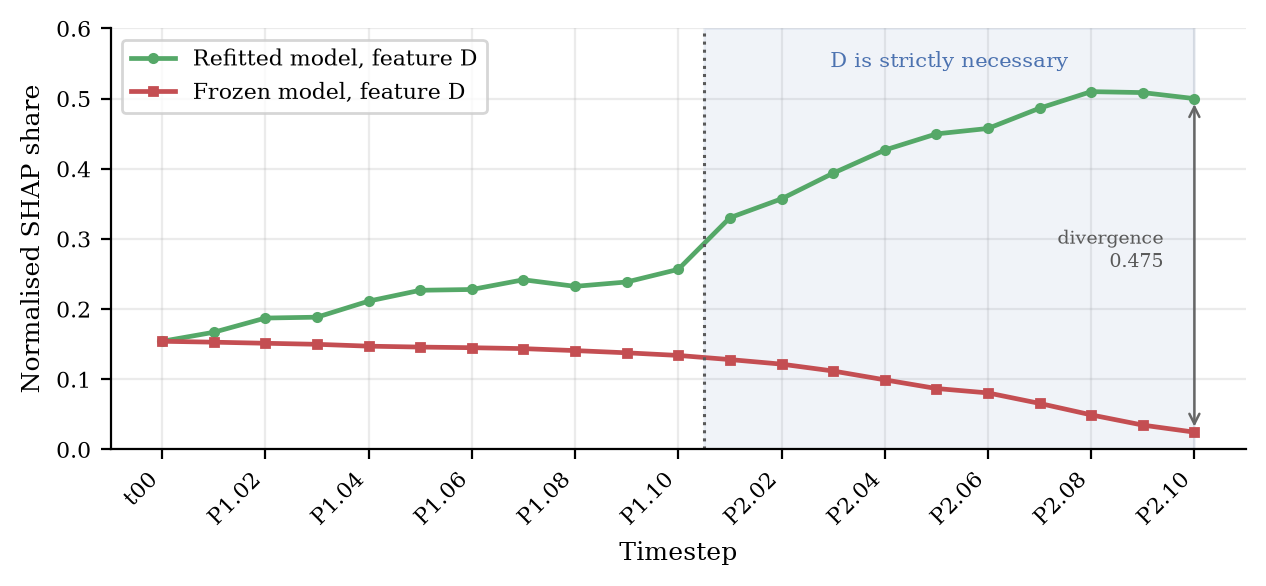

In [39]:
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(xs, sh["retr_D"], "o-", color=CB[2], ms=3, lw=1.7, label="Refitted model, feature D")
ax.plot(xs, sh["froz_D"], "s-", color=CB[3], ms=3, lw=1.7, label="Frozen model, feature D")
ax.axvspan(P2, xs[-1], color=CB[0], alpha=0.08)
ax.text((P2 + xs[-1]) / 2, 0.545, "D is strictly necessary", fontsize=7.5,
        ha="center", color=CB[0])

gap = sh["retr_D"].iloc[-1] - sh["froz_D"].iloc[-1]
ax.annotate("", xy=(xs[-1], sh["retr_D"].iloc[-1]), xytext=(xs[-1], sh["froz_D"].iloc[-1]),
            arrowprops=dict(arrowstyle="<->", color="0.4", lw=0.9))
ax.text(xs[-1] - 0.6, 0.26, f"divergence\n{gap:.3f}", fontsize=7, ha="right", color="0.35")

ax.set_ylabel("Normalised SHAP share")
ax.set_ylim(0, 0.60)
ax.legend(loc="upper left")
style(ax)
save(fig, "fig3_3_inversion.png")
print(f"D share  refitted {sh['retr_D'].iloc[0]:.3f} -> {sh['retr_D'].iloc[-1]:.3f}"
      f" | frozen {sh['froz_D'].iloc[0]:.3f} -> {sh['froz_D'].iloc[-1]:.3f}")

## Figure 3.7 — Accuracy of the Frozen and Refitted Arms

wrote ../figures/fig3_7_accuracy.png


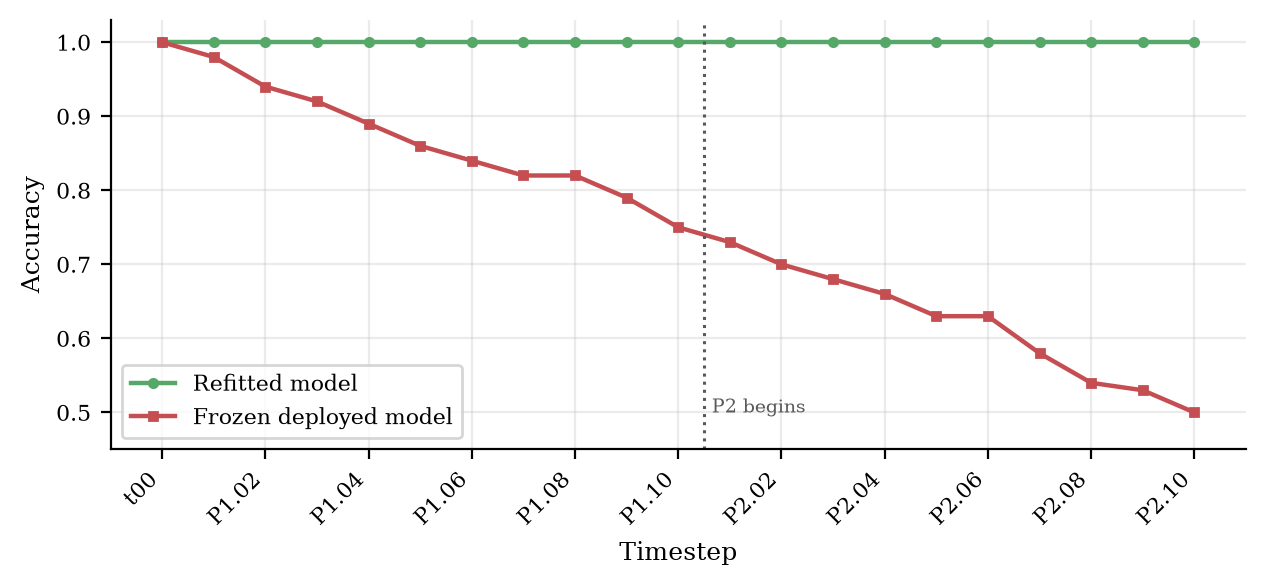

In [40]:
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(xs, res["retr_acc"], "o-", color=CB[2], ms=3, lw=1.6, label="Refitted model")
ax.plot(xs, res["froz_acc"], "s-", color=CB[3], ms=3, lw=1.6, label="Frozen deployed model")
ax.set_ylim(0.45, 1.03)
ax.set_ylabel("Accuracy")
ax.text(P2 + 0.15, 0.50, "P2 begins", fontsize=7, color="0.35")
ax.legend(loc="lower left")
style(ax)
save(fig, "fig3_7_accuracy.png")

## Figure 3.10 — Label-Free Vote Dominance against Frozen Accuracy

wrote ../figures/fig3_10_dominance.png


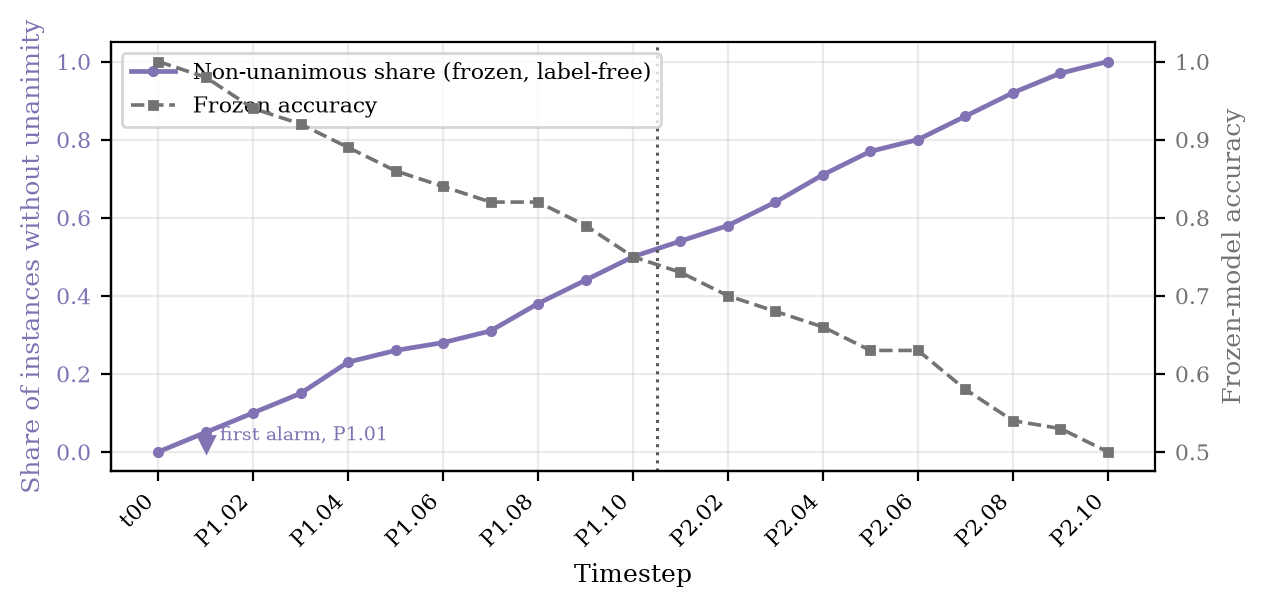

In [41]:
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(xs, res["frac_ne"], "o-", color=CB[4], ms=3, lw=1.7,
        label="Non-unanimous share (frozen, label-free)")
ax.set_ylabel("Share of instances without unanimity", color=CB[4])
ax.tick_params(axis="y", labelcolor=CB[4])

ax2 = ax.twinx()
ax2.plot(xs, res["froz_acc"], "s--", color="0.45", ms=3, lw=1.3, label="Frozen accuracy")
ax2.set_ylabel("Frozen-model accuracy", color="0.45")
ax2.tick_params(axis="y", labelcolor="0.45")
ax2.grid(False)

first_response = int(np.argmax(res["frac_ne"].to_numpy() > 0))
ax.plot(first_response, 0.02, marker="v", color=CB[4], ms=6, clip_on=False)
ax.text(first_response + 0.3, 0.03, f"first alarm, {T[first_response]}", fontsize=7, color=CB[4])

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left")
style(ax)
save(fig, "fig3_10_dominance.png")

## Figure 3.13 — L1 Departure against the Empirical Null Bands

signal                  null band   first alarm
Refitted impurity, L1   0.1027      P1.02
Refitted SHAP, L1       0.0712      P1.02
Frozen SHAP, L1         0.0712      P1.09
wrote ../figures/fig3_13_nullband.png


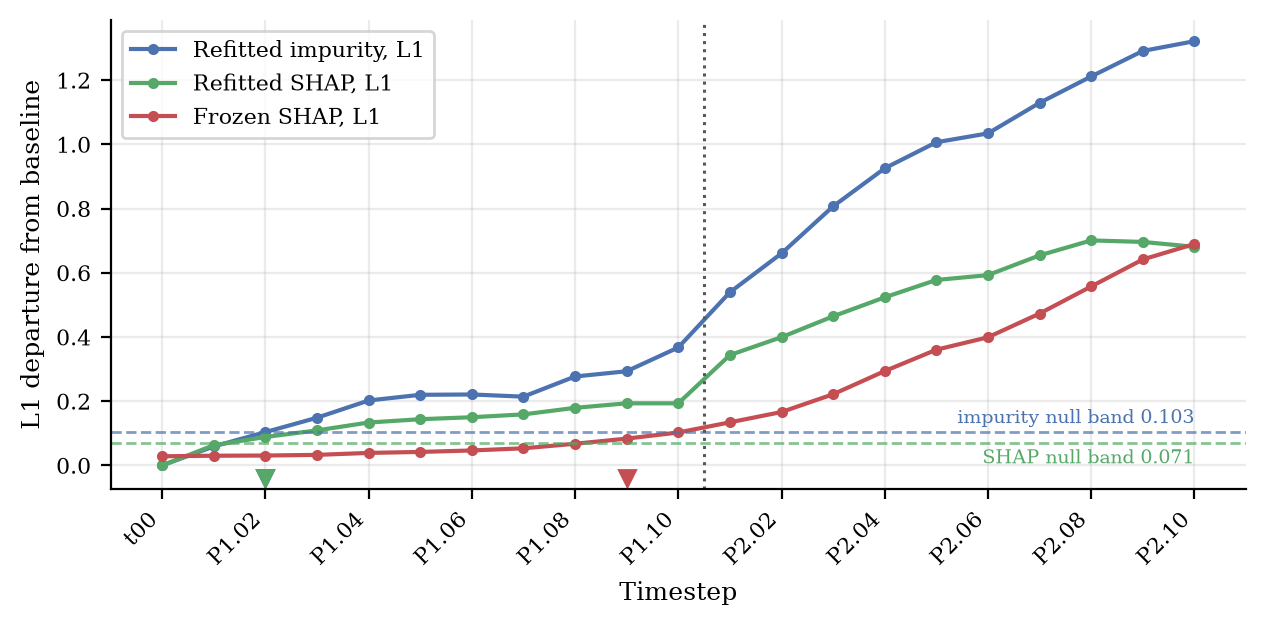

In [42]:
fig, ax = plt.subplots(figsize=(6.4, 3.2))
tracks = [("mdi_L1",      "Refitted impurity, L1", CB[0], null_mdi),
          ("shap_L1",     "Refitted SHAP, L1",     CB[2], null_shp),
          ("frozShap_L1", "Frozen SHAP, L1",       CB[3], null_shp)]

for col, label, colour, _ in tracks:
    ax.plot(xs, dep[col], "o-", color=colour, ms=3, lw=1.5, label=label)

ax.axhline(null_mdi, color=CB[0], ls="--", lw=1, alpha=0.7)
ax.axhline(null_shp, color=CB[2], ls="--", lw=1, alpha=0.7)
ax.text(20, null_mdi + 0.015, f"impurity null band {null_mdi:.3f}",
        fontsize=6.8, color=CB[0], ha="right", va="bottom")
ax.text(20, null_shp - 0.020, f"SHAP null band {null_shp:.3f}",
        fontsize=6.8, color=CB[2], ha="right", va="top")
ax.set_ylim(-0.075, None)

print(f"{'signal':<24}{'null band':<12}first alarm")
for col, label, colour, thr in tracks:
    over = np.where(dep[col].to_numpy() > thr)[0]
    ax.plot(over[0], -0.038, marker="v", color=colour, ms=6, clip_on=False)
    print(f"{label:<24}{thr:<12.4f}{T[over[0]]}")

ax.set_ylabel("L1 departure from baseline")
ax.legend(loc="upper left")
style(ax)
save(fig, "fig3_13_nullband.png")

## Canonical Verification

In [43]:
assert len(snaps) == 21
assert rep["n_pairs"].tolist() == [6] + [3] * 9 + [6] + [3] * 9 + [4]
assert rep["necessary"].tolist() == ["-"] * 11 + ["D"] * 10
assert (rep["relevant"] == "ACDE").tolist() == [False] * 11 + [True] * 9 + [False]
assert (res["retr_acc"] == 1.0).all()
assert round(float(res["froz_acc"].iloc[-1]), 2) == 0.50
assert round(float(sh["retr_D"].iloc[0]), 3) == 0.154
assert round(float(sh["retr_D"].iloc[-1]), 3) == 0.500
assert round(float(sh["froz_D"].iloc[-1]), 3) == 0.025
assert round(null_mdi, 4) == 0.1027 and round(null_shp, 4) == 0.0712


def _first(col, thr):
    return dep.loc[int(np.where(dep[col].to_numpy() > thr)[0][0]), "t"]


assert _first("mdi_L1", null_mdi) == "P1.02"
assert _first("shap_L1", null_shp) == "P1.02"
assert _first("frozShap_L1", null_shp) == "P1.09"
assert dep.loc[int(np.argmax(dep["frac_ne"].to_numpy() > 0)), "t"] == "P1.01"
assert DET_B[("frozen", "DDM")] // N == 1        # P1.01
assert DET_B[("frozen", "ADWIN")] // N == 8      # P1.08
assert DET_B[("retrained", "DDM")] is None and DET_B[("retrained", "ADWIN")] is None
print("Boolean-harness canonical values verified.")

Boolean-harness canonical values verified.


## Figure 3.5 — Reliance-Set Size and Feature Necessity

wrote ../figures/fig3_5_reliance_size_necessity.png


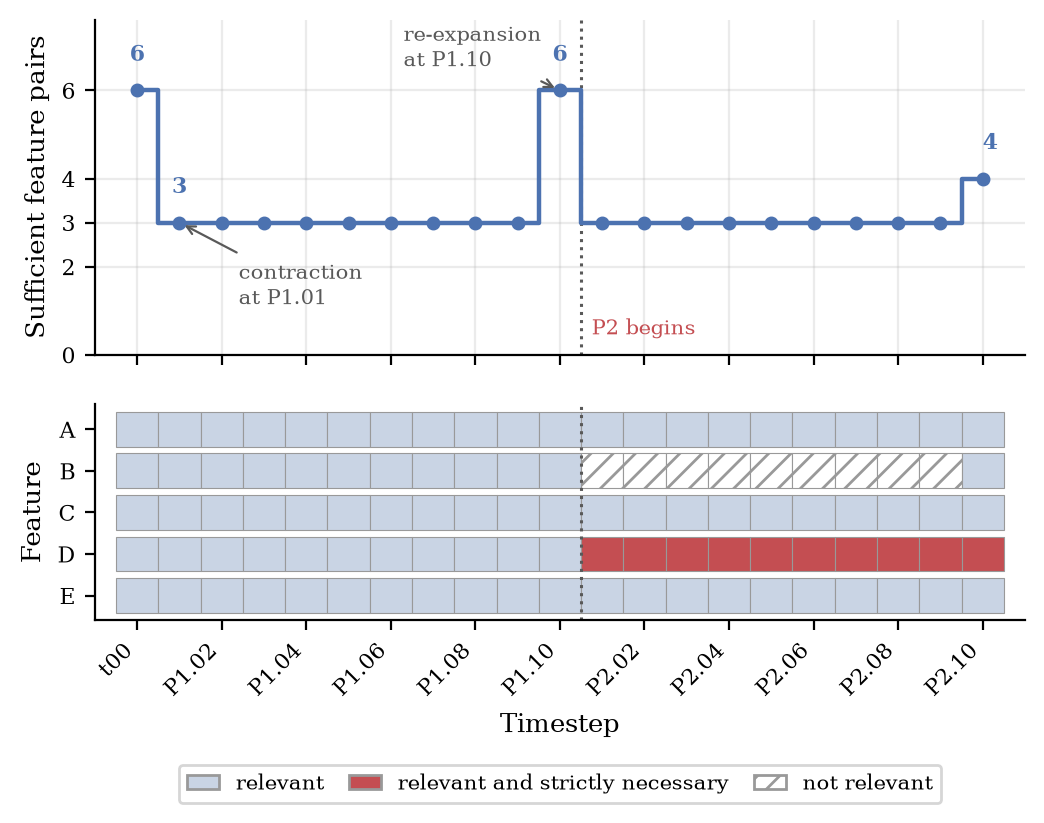

In [44]:
from matplotlib.patches import Rectangle, Patch

# larger base font for the remaining dissertation figures
plt.rcParams.update({"font.size": 9.5, "axes.labelsize": 9.5})

n_pairs = rep["n_pairs"].to_numpy()
REL = rep["relevant"].tolist()
NEC = rep["necessary"].tolist()

fig, (axa, axb) = plt.subplots(2, 1, figsize=(6.0, 3.9), sharex=True,
                               gridspec_kw={"height_ratios": [1.55, 1.0],
                                            "hspace": 0.18})
axa.step(xs, n_pairs, where="mid", color=CB[0], lw=1.6, zorder=3)
axa.plot(xs, n_pairs, "o", color=CB[0], ms=4.0, zorder=4)
axa.set_ylim(0, 7.6)
axa.set_yticks([0, 2, 3, 4, 6])
axa.set_ylabel("Sufficient feature pairs")
for i, ha in [(0, "center"), (1, "center"), (10, "center"), (20, "left")]:
    axa.text(xs[i], n_pairs[i] + 0.55, str(n_pairs[i]), fontsize=8.0, ha=ha,
             va="bottom", color=CB[0], fontweight="bold")
axa.annotate("contraction\nat P1.01", xy=(1, 3), xytext=(2.4, 1.15), fontsize=7.6,
             color="0.35", arrowprops=dict(arrowstyle="->", color="0.35", lw=0.8))
axa.annotate("re-expansion\nat P1.10", xy=(10, 6), xytext=(6.3, 6.55), fontsize=7.6,
             color="0.35", arrowprops=dict(arrowstyle="->", color="0.35", lw=0.8))
axa.axvline(P2, color="0.35", ls=":", lw=1.1)
axa.text(P2 + 0.25, 0.35, "P2 begins", fontsize=7.6, color=CB[3], va="bottom")
axa.spines["top"].set_visible(False)
axa.spines["right"].set_visible(False)

for j, feature in enumerate(FEATURES):
    y = len(FEATURES) - 1 - j
    for i in range(len(T)):
        nec = feature in NEC[i]
        rel = feature in REL[i]
        if nec:
            fc, hatch = CB[3], None
        elif rel:
            fc, hatch = "#C9D4E4", None
        else:
            fc, hatch = "white", "///"
        axb.add_patch(Rectangle((i - 0.5, y - 0.42), 1.0, 0.84, facecolor=fc,
                                edgecolor="0.6", lw=0.4, hatch=hatch, zorder=2))
axb.set_ylim(-0.6, len(FEATURES) - 0.4)
axb.set_yticks(range(len(FEATURES)))
axb.set_yticklabels(list(reversed(FEATURES)))
axb.set_ylabel("Feature")
axb.grid(False)
style(axb)
axb.legend(handles=[Patch(facecolor="#C9D4E4", edgecolor="0.6", label="relevant"),
                    Patch(facecolor=CB[3], edgecolor="0.6",
                          label="relevant and strictly necessary"),
                    Patch(facecolor="white", edgecolor="0.6", hatch="///",
                          label="not relevant")],
           loc="upper center", bbox_to_anchor=(0.5, -0.62), ncol=3, fontsize=7.6,
           handlelength=1.5, columnspacing=1.2)
save(fig, "fig3_5_reliance_size_necessity.png")

## Figure 3.6 — Sufficient-Pair Membership

wrote ../figures/fig3_6_sufficient_pair_heatmap.png


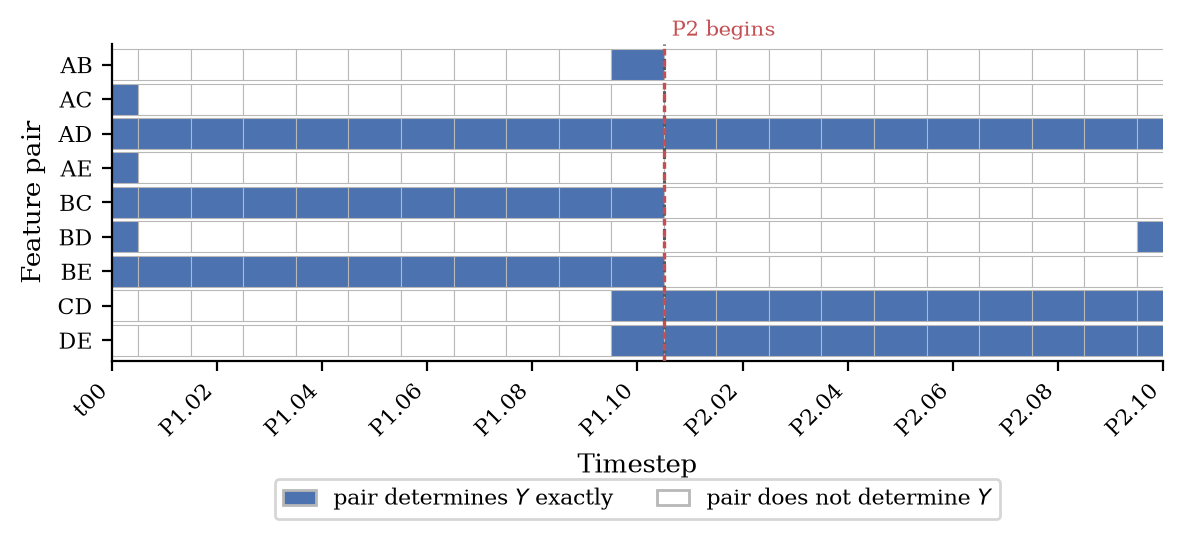

In [45]:
SUFF = []
for row in rep["sufficient pairs"].tolist():
    SUFF.append(row.split())

all_pairs_seen = set()
for row in SUFF:
    for pair in row:
        all_pairs_seen.add(pair)
ALL_PAIRS = sorted(all_pairs_seen)
assert ALL_PAIRS == ["AB", "AC", "AD", "AE", "BC", "BD", "BE", "CD", "DE"]

fig, ax = plt.subplots(figsize=(6.0, 3.05))
for r, pair in enumerate(ALL_PAIRS):
    y = len(ALL_PAIRS) - 1 - r
    for i in range(len(T)):
        on = pair in SUFF[i]
        ax.add_patch(Rectangle((i - 0.5, y - 0.45), 1.0, 0.9,
                               facecolor=(CB[0] if on else "white"),
                               edgecolor="0.72", lw=0.4, zorder=2))
ax.set_ylim(-0.6, len(ALL_PAIRS) - 0.4)
ax.set_yticks(range(len(ALL_PAIRS)))
ax.set_yticklabels(list(reversed(ALL_PAIRS)))
ax.set_ylabel("Feature pair")
ax.grid(False)
style(ax)
ax.axvline(P2, color=CB[3], ls=(0, (2, 1.4)), lw=1.2, zorder=6)
ax.text(P2 + 0.15, len(ALL_PAIRS) - 0.30, "P2 begins", fontsize=7.4,
        color=CB[3], ha="left", va="bottom")
ax.legend(handles=[Patch(facecolor=CB[0], edgecolor="0.72",
                         label="pair determines $Y$ exactly"),
                   Patch(facecolor="white", edgecolor="0.72",
                         label="pair does not determine $Y$")],
          loc="upper center", bbox_to_anchor=(0.5, -0.34), ncol=2, fontsize=7.8,
          handlelength=1.5)
save(fig, "fig3_6_sufficient_pair_heatmap.png")

## Figure 4.1 — First Response of Each Signal and Detector

Empirical, from `dep`, the null bands and `DET_B`.

wrote ../figures/fig4_1_boolean_first_response.png


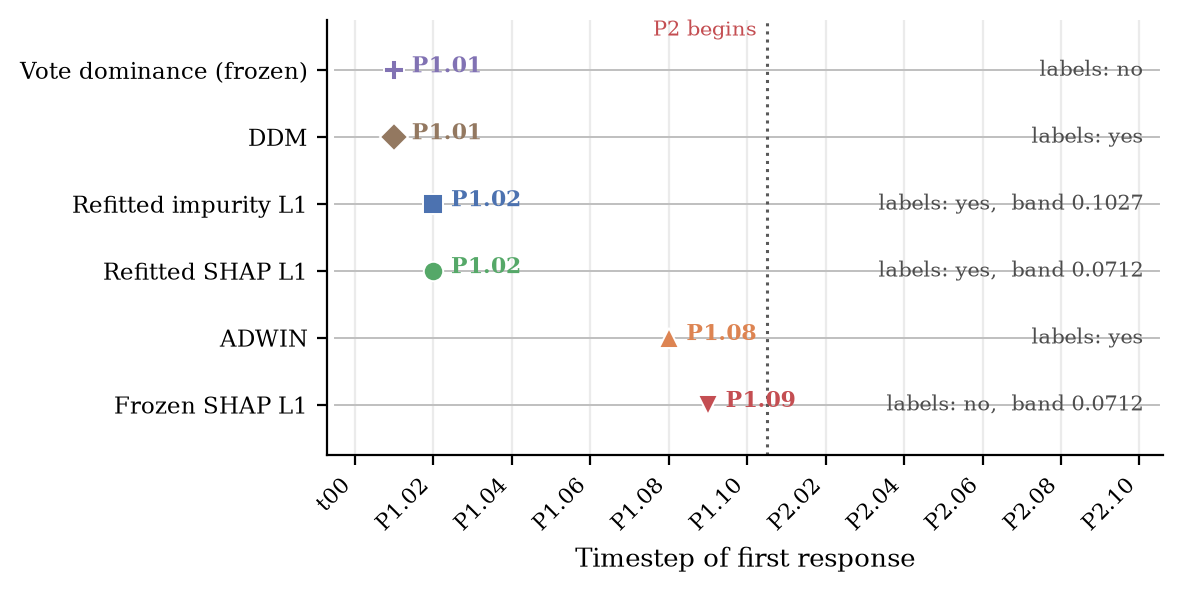

In [46]:
FIRST = {
    "Vote dominance (frozen)": (int(np.argmax(dep["frac_ne"].to_numpy() > 0)), "no", None),
    "DDM":                     (DET_B[("frozen", "DDM")] // N, "yes", None),
    "Refitted impurity L1":    (int(np.where(dep["mdi_L1"].to_numpy() > null_mdi)[0][0]),
                                "yes", null_mdi),
    "Refitted SHAP L1":        (int(np.where(dep["shap_L1"].to_numpy() > null_shp)[0][0]),
                                "yes", null_shp),
    "ADWIN":                   (DET_B[("frozen", "ADWIN")] // N, "yes", None),
    "Frozen SHAP L1":          (int(np.where(dep["frozShap_L1"].to_numpy() > null_shp)[0][0]),
                                "no", null_shp),
}
COLR = {"Vote dominance (frozen)": CB[4], "DDM": "#937860",
        "Refitted impurity L1": CB[0], "Refitted SHAP L1": CB[2],
        "ADWIN": CB[1], "Frozen SHAP L1": CB[3]}
MARK = {"Vote dominance (frozen)": "P", "DDM": "D", "Refitted impurity L1": "s",
        "Refitted SHAP L1": "o", "ADWIN": "^", "Frozen SHAP L1": "v"}
order = list(FIRST)

fig, ax = plt.subplots(figsize=(6.0, 3.05))
for k, name in enumerate(order):
    y = len(order) - 1 - k
    idx, lab, band = FIRST[name]
    ax.plot([-0.5, len(T) - 0.5], [y, y], color="0.75", lw=0.7, zorder=1)
    ax.plot(idx, y, marker=MARK[name], color=COLR[name], ms=7.0, zorder=4,
            mec="white", mew=0.7)
    ax.text(idx + 0.45, y + 0.055, T[idx], fontsize=8.0, va="center", ha="left",
            color=COLR[name], fontweight="bold")
    extra = "" if band is None else f",  band {band:.4f}"
    ax.text(len(T) - 0.9, y, f"labels: {lab}{extra}", fontsize=7.4, va="center",
            ha="right", color="0.3")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(list(reversed(order)), fontsize=8.2)
ax.set_ylim(-0.75, len(order) - 0.25)
ax.set_xlim(-0.7, len(T) - 0.4)
ax.set_xlabel("Timestep of first response")
ax.set_xticks(xs[::2])
ax.set_xticklabels(T[::2], rotation=45, ha="right")
ax.axvline(P2, color="0.35", ls=":", lw=1.1, zorder=2)
ax.text(P2 - 0.25, len(order) - 0.4, "P2 begins", fontsize=7.6, color=CB[3],
        ha="right", va="center")
ax.grid(axis="y", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
save(fig, "fig4_1_boolean_first_response.png")